# Extreme precipitation

### 10 year exceedance threshold

In [4]:
import numpy as np
import pandas
import pandas as pd
import glob
from lmoments3 import distr
from pandas import read_csv
import lmoments3.distr as distr

In [2]:
filepath = '/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Data/daily max pr era5/MAX_Precip_Wide_1995.csv'

def load_year(filepath):
    df = pd.read_csv(filepath, low_memory=False)  # or read_parquet, read_feather, etc.

    # Metadata columns to keep
    meta_cols = ['OBJECTID_1', 'REMARKS', 'STATE_LGD', 'STATE_UT', 'DIST_LGD',
                 'SUBDIS_LGD', 'SUBDIS_TYP', 'SUB_DIST', 'system:index',
                 'Shape_Area',	'Shape_Leng',	'.geo', 'DISTRICT', 'OBJECTID']

    # Date columns are everything else
    date_cols = [c for c in df.columns if c not in meta_cols]

    # Melt to long format: one row per subdistrict-day
    df_long = df.melt(
        id_vars=meta_cols,
        value_vars=date_cols,
        var_name='col_name',
        value_name='precip_max'
    )

    # Parse date from column name (format: YYYYMMDD_YYYY_MM_DD)
    df_long['date'] = pd.to_datetime(df_long['col_name'].str[:8], format='%Y%m%d')
    df_long['month'] = df_long['date'].dt.month
    df_long['year'] = df_long['date'].dt.year

    return df_long.drop(columns='col_name')

pr_1995 = load_year(filepath)
pr_1995.columns


Index(['OBJECTID_1', 'REMARKS', 'STATE_LGD', 'STATE_UT', 'DIST_LGD',
       'SUBDIS_LGD', 'SUBDIS_TYP', 'SUB_DIST', 'system:index', 'Shape_Area',
       'Shape_Leng', '.geo', 'DISTRICT', 'OBJECTID', 'precip_max', 'date',
       'month', 'year'],
      dtype='str')

In [3]:
pr_1995['STATE_UT'].unique()

<StringArray>
[       'ANDAMAN AND NICOBAR ISLANDS',                              'ASSAM',
                              'BIHAR',                         'CHANDIGARH',
                       'CHHATTISGARH',                              'DELHI',
                            'GUJARAT',                            'HARYANA',
                   'HIMACHAL PRADESH',                  'JAMMU AND KASHMIR',
                          'JHARKHAND',                             'LADAKH',
                     'MADHYA PRADESH',                        'MAHARASHTRA',
                            'MANIPUR',                            'MIZORAM',
                           'NAGALAND',                             'PUNJAB',
                          'RAJASTHAN',                            'TRIPURA',
                        'UTTARAKHAND',                       'UTTARPRADESH',
                                  nan,                                'GOA',
                         'PUDUCHERRY',                        

In [9]:
files = sorted(glob.glob('/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Data/daily max pr era5/*.csv'))

# Load and concatenate the data
df = pd.concat([load_year(f) for f in files], ignore_index=True)

# -------------------------------------------------------------------
# Define the custom year (July 1st to June 30th)
# -------------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])
# Assign custom year: If month is Jan-Jun (< 7), subtract 1 from the year.
# This groups Jul 1, 2023 to Jun 30, 2024 under custom_year '2023'.
df['custom_year'] = df['date'].dt.year - (df['date'].dt.month < 7).astype(int)

print(df.shape)
print(df.head())

(75490441, 19)
   OBJECTID_1 REMARKS  STATE_LGD                     STATE_UT DIST_LGD  \
0         189     NaN       35.0  ANDAMAN AND NICOBAR ISLANDS      638   
1         192     NaN       35.0  ANDAMAN AND NICOBAR ISLANDS      638   
2         197     NaN       35.0  ANDAMAN AND NICOBAR ISLANDS      638   
3         190     NaN       35.0  ANDAMAN AND NICOBAR ISLANDS      639   
4         194     NaN       35.0  ANDAMAN AND NICOBAR ISLANDS      639   

  SUBDIS_LGD    SUBDIS_TYP       SUB_DIST          system:index    Shape_Area  \
0      05916  Sub_District    CAR NICOBAR  00000000000000000099  1.382585e+08   
1      05918  Sub_District  GREAT NICOBAR  0000000000000000009c  1.195501e+09   
2      05917  Sub_District       NANCOWRY  000000000000000000a1  5.207588e+08   
3      05919  Sub_District       DIGLIPUR  0000000000000000009a  1.438895e+09   
4      05920  Sub_District     MAYABUNDER  0000000000000000009e  7.714809e+08   

     Shape_Leng                                      

In [5]:
# Group by the NEW custom_year instead of the standard year
annual_max_df = df.groupby(['STATE_UT', 'DISTRICT', 'SUB_DIST', 'custom_year']).agg(
    annual_max=('precip_max', 'max')
).reset_index()

results = []
# Filter on custom_year instead of year
for (state, district), group in annual_max_df[annual_max_df['custom_year'] <= 2025].groupby(['STATE_UT', 'DISTRICT']):
    vals = group['annual_max'].dropna().values

    if len(vals) < 10:   # optional: avoid unstable fits
        continue

    params = distr.gev.lmom_fit(vals)
    tau = distr.gev.ppf(0.90, **params)

    results.append({
        'STATE': state,
        'DISTRICT': district,
        'THRESHOLD_10YR': tau
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(results)
threshold_df.to_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/thresholds_custom_year.csv", index=False)
threshold_df.to_excel("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/thresholds_custom_year.xlsx", index=False)

(75490441, 19)
   OBJECTID_1 REMARKS  STATE_LGD                     STATE_UT DIST_LGD  \
0         189     NaN       35.0  ANDAMAN AND NICOBAR ISLANDS      638   
1         192     NaN       35.0  ANDAMAN AND NICOBAR ISLANDS      638   
2         197     NaN       35.0  ANDAMAN AND NICOBAR ISLANDS      638   
3         190     NaN       35.0  ANDAMAN AND NICOBAR ISLANDS      639   
4         194     NaN       35.0  ANDAMAN AND NICOBAR ISLANDS      639   

  SUBDIS_LGD    SUBDIS_TYP       SUB_DIST          system:index    Shape_Area  \
0      05916  Sub_District    CAR NICOBAR  00000000000000000099  1.382585e+08   
1      05918  Sub_District  GREAT NICOBAR  0000000000000000009c  1.195501e+09   
2      05917  Sub_District       NANCOWRY  000000000000000000a1  5.207588e+08   
3      05919  Sub_District       DIGLIPUR  0000000000000000009a  1.438895e+09   
4      05920  Sub_District     MAYABUNDER  0000000000000000009e  7.714809e+08   

     Shape_Leng                                      

Join it wih the threshold from the 2 missing states (calculated in another ipynb)

In [27]:
# Join it wih the threshold from the 2 missing states (calculated in another ipynb)

threshold_missing = pd.read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/thresholds_custom_year_2states.csv")
threshold_df = pd.read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/thresholds_custom_year.csv")

threshold_full = pd.concat([threshold_df, threshold_missing], ignore_index=True)
threshold_full.to_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/final material/thresholds_custom_year_infull.csv")
print(f"Successfully joined! Total states: {threshold_full["STATE"].nunique()}")
print(threshold_full['STATE'].unique())

Successfully joined! Total states: 35
<StringArray>
[       'ANDAMAN AND NICOBAR ISLANDS',                     'ANDHRA PRADESH',
                              'ASSAM',                              'BIHAR',
                         'CHANDIGARH',                       'CHHATTISGARH',
 'DADRA & NAGAR HAVELI & DAMAN & DIU',                              'DELHI',
                                'GOA',                            'GUJARAT',
                            'HARYANA',                   'HIMACHAL PRADESH',
                  'JAMMU AND KASHMIR',                          'JHARKHAND',
                          'KARNATAKA',                             'KERALA',
                             'LADAKH',                     'MADHYA PRADESH',
                        'MAHARASHTRA',                            'MANIPUR',
                            'MIZORAM',                           'NAGALAND',
                             'ODISHA',                         'PUDUCHERRY',
                        

### Exceedance count (only for the districts with subdistricts)

We use threshold_full later on to build an alternative flash flood index based only on precipitation.

In [7]:
threshold_df = pd.read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/thresholds_custom_year.csv")

In [8]:
threshold_df['STATE'].nunique()

33

In [10]:
# for each district count the number of exceedance per custom year
# 1. Merge the thresholds back into the main daily dataframe
exceedance_df = df.merge(
    threshold_df,
    left_on=['STATE_UT', 'DISTRICT'],
    right_on=['STATE', 'DISTRICT'],
    how='inner'
)

# 2. Identify where daily precipitation exceeds the 10-year threshold
exceedance_df['is_exceedance'] = exceedance_df['precip_max'] > exceedance_df['THRESHOLD_10YR']

In [11]:
exceedance_df = exceedance_df.sort_values(by=['STATE_UT', 'DISTRICT', 'SUB_DIST', 'date'])
exceedance_df['prev_is_exceedance'] = (
    exceedance_df.groupby(['STATE_UT', 'DISTRICT', 'SUB_DIST'])['is_exceedance']
    .shift(1)
    .fillna(False)
)

# A new event starts for a sub-district if it exceeds today but didn't yesterday
exceedance_df['is_new_event_sub'] = exceedance_df['is_exceedance'] & ~exceedance_df['prev_is_exceedance']

# 3. Aggregate to District-Day level
# Rule: If ANY sub-district starts an event, the district gets 1 event start for that day.
# Rule: If ANY sub-district exceeds the threshold, the district gets 1 exceedance day.
district_daily = exceedance_df.groupby(['STATE_UT', 'DISTRICT', 'custom_year', 'date']).agg(
    district_event_start=('is_new_event_sub', 'any'),
    district_exceeded=('is_exceedance', 'any')
).reset_index()

# 4. Final Aggregation to Custom Year
# We sum the daily booleans (True=1, False=0)
exceedance_counts = district_daily.groupby(['STATE_UT', 'DISTRICT', 'custom_year']).agg(
    event_count=('district_event_start', 'sum'),
    exceedance_days_total=('district_exceeded', 'sum')
).reset_index()

In [12]:
# 4. Save the results
exceedance_counts.to_excel("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/exceedance_counts_per_custom_year_events.xlsx", index=False)
exceedance_counts.to_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/exceedance_counts_per_custom_year_events.csv", index=False)


### Aggregation to state level (population weights)

This excludes Meghalaya and Arunachal Pradesh.

In [43]:
# Compute population-weighted state average
pop_df = read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/district_population.csv")

# Merge data
merged_df = exceedance_counts.merge(
    pop_df[['DISTRICT', 'pop_total']],
    on='DISTRICT',
    how='inner'
)

In [46]:
# Exposure = Exceedance Count * Population
merged_df['pop_exposure'] = merged_df['event_count'] * merged_df['pop_total']

state_scores = merged_df.groupby(['STATE_UT', 'custom_year']).agg(
    total_exposure=('pop_exposure', 'sum'),
    total_state_pop=('pop_total', 'sum')
).reset_index()

# The weighted score: average exceedances per person in the state
state_scores['weighted_score'] = state_scores['total_exposure'] / state_scores['total_state_pop']

In [47]:
print(state_scores.head())

state_scores.to_excel("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/states_scores_beta.xlsx", index=False)


                      STATE_UT  custom_year  total_exposure  total_state_pop  \
0  ANDAMAN AND NICOBAR ISLANDS         1993             0.0    397624.511719   
1  ANDAMAN AND NICOBAR ISLANDS         1994             0.0    397624.511719   
2  ANDAMAN AND NICOBAR ISLANDS         1995             0.0    397624.511719   
3  ANDAMAN AND NICOBAR ISLANDS         1996             0.0    397624.511719   
4  ANDAMAN AND NICOBAR ISLANDS         1997             0.0    397624.511719   

   weighted_score  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             0.0  


### Plotting

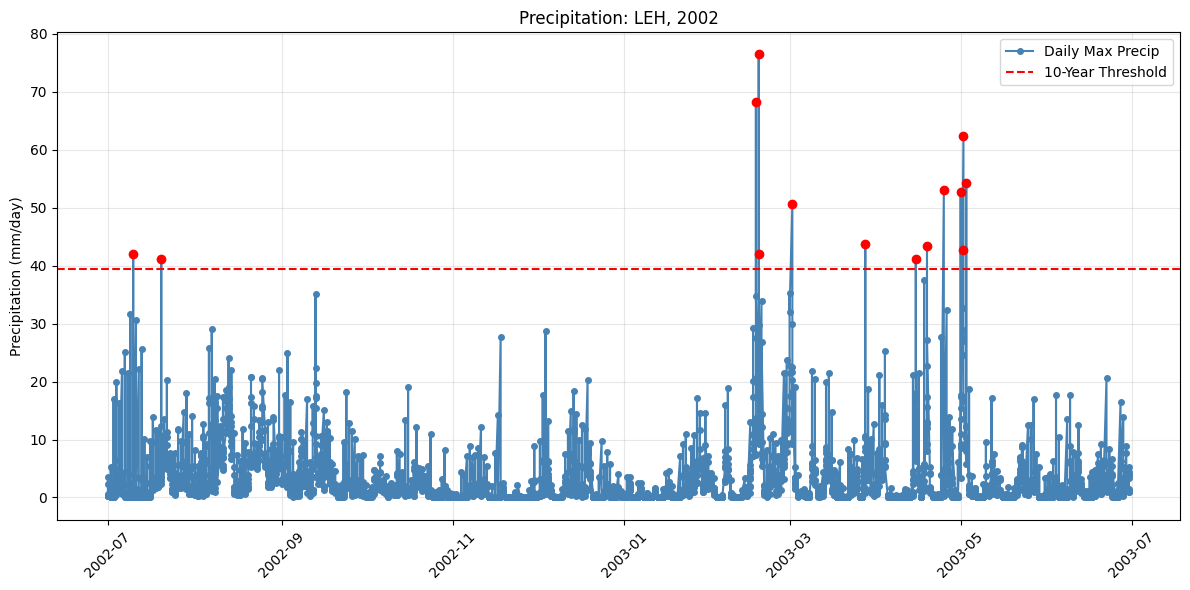

In [41]:
def plot_district_precipitation(df, threshold_df, target_district, target_custom_year,
                               start_date=None, end_date=None):
    # 1. Filter for district and custom year
    district_data = df[
        (df['DISTRICT'] == target_district) &
        (df['custom_year'] == target_custom_year)
    ].sort_values('date')

    if district_data.empty:
        print("No data found.")
        return

    # 2. ZOOM LOGIC: Filter by specific date range if provided
    if start_date and end_date:
        district_data = district_data[
            (district_data['date'] >= start_date) &
            (district_data['date'] <= end_date)
        ]

    # 3. Get Threshold
    threshold = threshold_df[threshold_df['DISTRICT'] == target_district]['THRESHOLD_10YR'].item()

    # 4. Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(district_data['date'], district_data['precip_max'],
             label='Daily Max Precip', color='steelblue', marker='o', markersize=4)

    plt.axhline(y=threshold, color='red', linestyle='--', label='10-Year Threshold')

    # Highlight exceedances within this zoom window
    exceedances = district_data[district_data['precip_max'] > threshold]
    plt.scatter(exceedances['date'], exceedances['precip_max'], color='red', zorder=5)

    plt.title(
    f"Precipitation: {target_district}, {target_custom_year}" if start_date is None
    else f"Zoomed View: {target_district} ({start_date} to {end_date})")
    plt.ylabel("Precipitation (mm/day)")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
plot_district_precipitation(
    df,
    threshold_df,
    target_district="LEH",
    target_custom_year=2002,
)

### Alternative (robustness index): Flash flood index based only on extreme precipitation

Exceedance count for all districts: count the number of events per year. An event is defined by:

- at least one subdistrict (district*) exceeds the threshold.
- two events are separated by at least one day below the threshold in the subdistrict (district*).
- there is a cap of 1 event/district per day (e.g. is two subdistrict exceed the threshold, it will be counted as one event).

_* the subdistrict scale is used, expect for the states of Meghalaya and Arunachal Pradesh, for which subdistrict boundaries are not available in the shapefile and so I use district boundaries._

The exceedance count for the two mising states is processed in another file (flood_index_complement.ipynb). Here we simply join the 2.

In [60]:
df1 = pd.read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/exceedance_counts_per_custom_year_events.csv")
df2 = pd.read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/exceedance_counts_per_custom_year_events_2states.csv")
combined_exceedance = pd.concat([df1, df2], ignore_index=True)

In [61]:
print(combined_exceedance.head())

                      STATE_UT  DISTRICT  custom_year  event_count  \
0  ANDAMAN AND NICOBAR ISLANDS  NICOBARS         1993            0   
1  ANDAMAN AND NICOBAR ISLANDS  NICOBARS         1994            0   
2  ANDAMAN AND NICOBAR ISLANDS  NICOBARS         1995            0   
3  ANDAMAN AND NICOBAR ISLANDS  NICOBARS         1996            0   
4  ANDAMAN AND NICOBAR ISLANDS  NICOBARS         1997            0   

   exceedance_days_total  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  


Aggregate to state-level using population weights

In [ ]:
# compute population-weighted state average
pop_df = read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/district_population.csv")

In [62]:
combined_exceedance['STATE_UT'].nunique()
combined_exceedance['STATE_UT'] = combined_exceedance['STATE_UT'].replace({'UTTARPRADESH': 'UTTAR PRADESH'})

In [69]:
merged_df = combined_exceedance.merge(
    pop_df[['DISTRICT', 'pop_total']],
    on='DISTRICT',
    how='inner')

In [70]:
# DEBUGGING
print(pop_df['STATE_UT'].nunique())
print(combined_exceedance['STATE_UT'].nunique())
#print(merged_df['STATE_UT'].unique())

# What's in pop_df but not in combined_exceedance
print("Missing from combined_exceedance:",
      set(pop_df['STATE_UT'].unique()) - set(combined_exceedance['STATE_UT'].unique()))

# What's in combined_exceedance but not in merged_df
print("Lost after merge:",
      set(combined_exceedance['STATE_UT'].unique()) - set(merged_df['STATE_UT'].unique()))

36
35
Missing from combined_exceedance: {'LAKSHADWEEP', nan}
Lost after merge: set()


In [66]:
"""for state in ['PUNJAB', 'TRIPURA']:
    exc = set(combined_exceedance[combined_exceedance['STATE_UT'] == state]['DISTRICT'])
    pop = set(pop_df[pop_df['STATE_UT'] == state]['DISTRICT'])
    print(f"\n{state}")
    print("Only in exceedance:", exc - pop)
    print("Only in pop_df:", pop - exc)"""

# Normalize casing in both dfs
for state in ['PUNJAB', 'TRIPURA']:
    mask_exc = combined_exceedance['STATE_UT'] == state
    mask_pop = pop_df['STATE_UT'] == state
    combined_exceedance.loc[mask_exc, 'DISTRICT'] = combined_exceedance.loc[mask_exc, 'DISTRICT'].str.upper().str.strip()
    pop_df.loc[mask_pop, 'DISTRICT'] = pop_df.loc[mask_pop, 'DISTRICT'].str.upper().str.strip()

# Fix Punjab name mismatches
combined_exceedance['DISTRICT'] = combined_exceedance['DISTRICT'].replace({
    'MUKTSAR': 'SRI MUKTSAR SAHIB',
    'SAHIBZADA AJIT SINGH NAGAR': 'SAS NAGAR (SAHIBZADA AJIT SINGH NAGAR)',
    'MALERKOTLA': 'MALER KOTLA',
})

In [ ]:
merged_df = combined_exceedance.merge(
    pop_df[['DISTRICT', 'pop_total']],
    on='DISTRICT',
    how='inner'
)

In [71]:
print(merged_df['STATE_UT'].nunique())

35


In [72]:
print(pop_df['STATE_UT'].nunique())
print(combined_exceedance['STATE_UT'].nunique())
print(merged_df['STATE_UT'].nunique())
# Exposure = Exceedance Count * Population
merged_df['pop_exposure'] = merged_df['event_count'] * merged_df['pop_total']

combined_state_scores = merged_df.groupby(['STATE_UT', 'custom_year']).agg(
    total_exposure=('pop_exposure', 'sum'),
    total_state_pop=('pop_total', 'sum')
).reset_index()

# The weighted score: average exceedances per person in the state
combined_state_scores['weighted_score'] = combined_state_scores['total_exposure'] / combined_state_scores['total_state_pop']

print(combined_state_scores.head())
# print(combined_state_scores['STATE_UT'].nunique())


combined_state_scores.to_excel("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/combined_states_scores_new.xlsx", index=False)
combined_state_scores.to_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/combined_states_scores_new.csv", index=False)

36
35
35
                      STATE_UT  custom_year  total_exposure  total_state_pop  \
0  ANDAMAN AND NICOBAR ISLANDS         1993             0.0    397624.511719   
1  ANDAMAN AND NICOBAR ISLANDS         1994             0.0    397624.511719   
2  ANDAMAN AND NICOBAR ISLANDS         1995             0.0    397624.511719   
3  ANDAMAN AND NICOBAR ISLANDS         1996             0.0    397624.511719   
4  ANDAMAN AND NICOBAR ISLANDS         1997             0.0    397624.511719   

   weighted_score  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             0.0  


In [73]:
combined_state_scores['STATE_UT'].nunique()

35

# Soil moisture integration

Now we combine the subdistrict level event database with the soil moisture anomaly data. I do so in the following way: for each detected event at the subdistrict level, instead of the value 1 (1 = event occurs, 0 = no event), I assign the value 1 + soil moisture anomaly. This means all values will be between 0 and 2, depending on the antecedent soil moisture (ie average soil moisture over the 5 days prior to the first extreme precipitation day). This is the subdistrict level flood index. I average the non-0 flood index values to create the district-level flood index values. Finally, I compute the sum of the flood indices over the year (July to June) per district. This is the district level yearly flood index. Using population weights I aggregate them to state-level and obtain yearly state-level flood index.

In sum, the state-level flood index is the sum of all extreme precipitation events that hit that state, multiplied by the relative soil moisture on that day (with respect tp the normal state moisture). This approach emphasizes frequency of events rather than intensity. Though the threshold should be high enough that only crazy precipitation is recorded for the flood index. Soil moisture probably doesn't make that big a difference. I can make some plots and compare, but mostly we'll see in the regression if it makes a difference to look at the "raw" extreme precipitation events count vs the soil moisture weighted final index.

In practice the code goes as follows: detect event, save the date, check the date on the sm df and get the sm value, add 1, average for that date if there are several subdistricts (or take the maximum? Actually yes this is better!!!)

**The code for this is in final_flood_score.ipynb**